# Random Forest

### Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('vehicle_maintenance_data.csv')
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,11/23/2023,6/24/2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,9/21/2023,6/4/2025,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,6/27/2023,4/27/2025,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,8/24/2023,11/5/2025,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,5/25/2023,9/14/2025,Third,16446,6,2,16.977483,Good,Good,Weak,1


In [2]:
df['Last_Service_Date'] = pd.to_datetime(df['Last_Service_Date'])
df['Warranty_Expiry_Date'] = pd.to_datetime(df['Warranty_Expiry_Date'])

In [3]:
df[['Service_History', 'Accident_History', 'Reported_Issues']]
df['Hist_Record'] = (df['Service_History'] + df['Accident_History'] + df['Reported_Issues']) /  3

df_updated = df.copy()

df_updated.drop(columns= ['Service_History', 'Accident_History', 'Reported_Issues'], axis= 1, inplace= True)

df_updated.head()

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Hist_Record
0,Truck,58765,Good,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,13.622204,New,New,Weak,1,3.000000
1,Van,60353,Average,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,13.625307,New,New,Weak,1,2.666667
2,Bus,68072,Poor,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,14.306302,New,Good,Weak,1,2.333333
3,Bus,60849,Average,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,18.709467,New,Worn Out,New,1,4.666667
4,Bus,45742,Poor,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,16.977483,Good,Good,Weak,1,4.333333


In [4]:
object_col = []

for i in df_updated.columns:
    if df[i].dtype == 'object':
        object_col.append(i)

encoder = LabelEncoder()

for encoded in object_col:
    df_updated[encoded] = encoder.fit_transform(df_updated[encoded])

df_updated

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Hist_Record
0,4,58765,1,4,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,1,2,1,3.000000
1,5,60353,0,7,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,1,2,1,2.666667
2,0,68072,2,2,1,0,1500,34022,2023-06-27,2025-04-27,0,17979,14.306302,1,0,2,1,2.333333
3,0,60849,0,5,2,0,2500,81636,2023-08-24,2025-11-05,1,6220,18.709467,1,2,1,1,4.666667
4,0,45742,2,1,2,1,2000,97162,2023-05-25,2025-09-14,2,16446,16.977483,0,0,2,1,4.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1,77229,1,6,0,0,2500,97404,2023-11-24,2025-09-15,2,5217,10.357298,1,0,2,1,2.666667
49996,4,54742,1,4,0,1,800,13421,2023-07-14,2025-01-21,1,15856,14.924022,2,1,0,1,3.000000
49997,5,75601,2,4,1,0,1500,124851,2023-09-09,2024-11-09,0,6019,19.859243,2,2,2,1,3.333333
49998,1,66181,1,7,1,1,2500,103182,2023-08-26,2025-05-22,2,5030,10.720555,1,0,2,1,2.666667


In [5]:
df_updated['service_status'] = df_updated['Tire_Condition'] + df_updated['Brake_Condition'] + df_updated['Battery_Status'] / 3

df_updated.drop(columns=['Tire_Condition', 'Brake_Condition', 'Battery_Status'], inplace= True, axis = 1)

df_updated.head(2)

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,Hist_Record,service_status
0,4,58765,1,4,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,3.000000,2.666667
1,5,60353,0,7,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,2.666667,2.666667


In [6]:
df_updated['miles_per_year'] = df_updated['Mileage'] / df['Vehicle_Age']

df_updated.drop(columns=['Mileage', 'Vehicle_Age'], inplace= True, axis= 1)

df_updated.describe()

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,Hist_Record,service_status,miles_per_year
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.503700,0.996800,0.99884,0.500180,1556.292000,75551.187060,2023-09-13 10:33:48.096000,2025-04-11 15:56:30.336000256,1.002700,17465.340700,14.990323,0.809960,3.171513,2.335213,16135.339941
min,0.000000,0.000000,0.00000,0.000000,800.000000,1001.000000,2023-03-30 00:00:00,2024-04-28 00:00:00,0.000000,5000.000000,10.000098,0.000000,0.333333,0.000000,3000.500000
25%,1.000000,0.000000,0.00000,0.000000,1000.000000,38009.000000,2023-06-21 00:00:00,2024-10-18 00:00:00,0.000000,11189.750000,12.489037,1.000000,2.333333,1.333333,6780.325000
50%,3.000000,1.000000,1.00000,1.000000,1500.000000,75598.500000,2023-09-14 00:00:00,2025-04-12 00:00:00,1.000000,17477.500000,14.986352,1.000000,3.333333,2.333333,10030.166667
75%,4.000000,2.000000,2.00000,1.000000,2000.000000,112999.500000,2023-12-06 00:00:00,2025-10-04 00:00:00,2.000000,23692.000000,17.474676,1.000000,4.000000,3.333333,18389.500000
max,5.000000,2.000000,2.00000,1.000000,2500.000000,149999.000000,2024-02-28 00:00:00,2026-03-29 00:00:00,2.000000,30000.000000,19.999968,1.000000,6.000000,4.666667,79990.000000
std,1.711422,0.815943,0.81754,0.500005,627.677218,43088.105658,NaN,NaN,0.813945,7223.393401,2.885583,0.392336,1.176649,1.186846,15588.301259


In [7]:
df_updated['total_hist_service'] = df_updated['Hist_Record'] + df_updated['service_status'] / 2 

df_updated.drop(columns=['Hist_Record', 'service_status'], inplace= True, axis= 1)

In [8]:
df_updated['last_Service_month'] = df_updated['Last_Service_Date'].dt.month
df_updated['Last_Service_Date'].dt.dayofweek.value_counts()

df_updated['week_number'] = df_updated['Last_Service_Date'].dt.isocalendar().week
df_updated.drop(columns=['Last_Service_Date', 'Warranty_Expiry_Date'], axis= 1, inplace= True)

df_updated.head(3)

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,miles_per_year,total_hist_service,last_Service_month,week_number
0,4,1,1,0,2000,28524,1,20782,13.622204,1,14691.250000,4.333333,11,47
1,5,0,1,0,2500,133630,1,23489,13.625307,1,8621.857143,4.000000,9,38
2,0,2,1,0,1500,34022,0,17979,14.306302,1,34036.000000,3.166667,6,26


## Modeling


### Train/Test Split

In [12]:
from sklearn.model_selection import train_test_split

X = df_updated.drop(columns=["Need_Maintenance"])
y = df_updated["Need_Maintenance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")

X_train shape: (40000, 13)
X_test shape:  (10000, 13)
y_train distribution:
Need_Maintenance
1    0.80995
0    0.19005
Name: proportion, dtype: float64


### Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaled numeric columns:", list(numeric_cols))

Scaled numeric columns: ['Vehicle_Model', 'Maintenance_History', 'Fuel_Type', 'Transmission_Type', 'Engine_Size', 'Odometer_Reading', 'Owner_Type', 'Insurance_Premium', 'Fuel_Efficiency', 'miles_per_year', 'total_hist_service']


### Train Random Forest Classifier

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)
print("Random Forest training complete.")

Random Forest training complete.


### Evaluate Model Performance

Classification Report:
              precision    recall  f1-score   support

           0     0.5953    0.2005    0.3000      1900
           1     0.8377    0.9680    0.8982      8100

    accuracy                         0.8222     10000
   macro avg     0.7165    0.5843    0.5991     10000
weighted avg     0.7917    0.8222    0.7845     10000

Confusion Matrix:
 [[ 381 1519]
 [ 259 7841]]
Test ROC-AUC: 0.7878


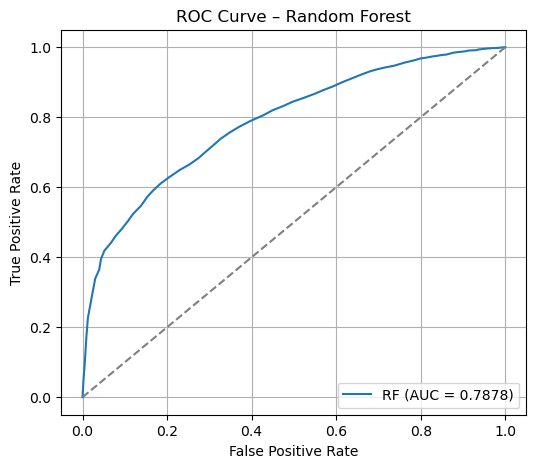

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"RF (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Feature Importance

Top 10 Feature Importances:
           feature  importance
total_hist_service    0.215449
    miles_per_year    0.118863
 Insurance_Premium    0.118542
   Fuel_Efficiency    0.118450
  Odometer_Reading    0.118207
       week_number    0.082518
last_Service_month    0.045073
     Vehicle_Model    0.045006
       Engine_Size    0.040618
        Owner_Type    0.028900


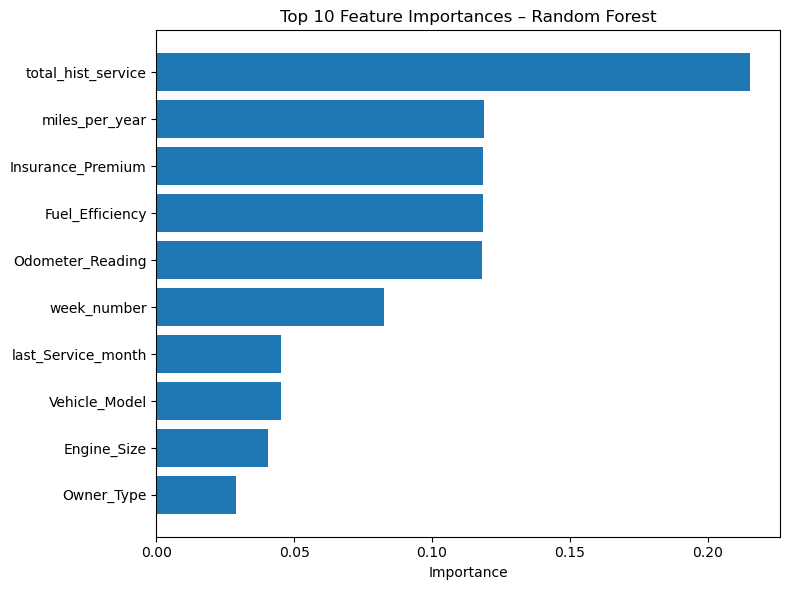

In [16]:
import pandas as pd

importances = rf_clf.feature_importances_
feat_names = X_train.columns

feat_imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("Top 10 Feature Importances:")
print(feat_imp_df.head(10).to_string(index=False))

plt.figure(figsize=(8, 6))
plt.barh(
    feat_imp_df["feature"].head(10)[::-1],
    feat_imp_df["importance"].head(10)[::-1]
)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances – Random Forest")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning 

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Classification Report (Best RF):")
print(classification_report(y_test, y_pred_best, digits=4))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV F1-score: 0.8989
Classification Report (Best RF):
              precision    recall  f1-score   support

           0     0.6605    0.1311    0.2187      1900
           1     0.8284    0.9842    0.8996      8100

    accuracy                         0.8221     10000
   macro avg     0.7445    0.5576    0.5592     10000
weighted avg     0.7965    0.8221    0.7702     10000



### Save and Upload Model

In [32]:
import boto3, sagemaker

sagemaker_session = sagemaker.Session()
bucket = sagemaker_session.default_bucket()
prefix = "rf-models"

s3 = boto3.client("s3")
s3_key = f"{prefix}/rf_model.tar.gz"
s3.upload_file("rf_model.tar.gz", bucket, s3_key)

model_data = f"s3://{bucket}/{s3_key}"
print("New RF model archive uploaded to:", model_data)


New RF model archive uploaded to: s3://sagemaker-us-east-1-952836627286/rf-models/rf_model.tar.gz


In [35]:
import joblib
import numpy as np

try:
    from sagemaker_inference import content_types, decoder, encoder
except ImportError:
    # We’re running outside of SageMaker; define dummies so the file still loads
    content_types = type("ct", (), {"JSON": "application/json", "CSV": "text/csv"})
    decoder = type("dc", (), {"decode": lambda body, ct: {"instances": [[0]]}})
    encoder = type("enc", (), {"encode": lambda prediction, accept: str(prediction)})

model_path = "rf_model.joblib"
rf = joblib.load(model_path)


In [36]:
import joblib
rf_test = joblib.load("rf_model.joblib")
print("Loaded OK:", type(rf_test))


Loaded OK: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


### Write Inference Script

In [37]:
%%bash
cat << 'EOF' > inference_rf.py
import joblib
import numpy as np
from sagemaker_inference import content_types, decoder, encoder

model_path = "/opt/ml/model/rf_model.joblib"
rf = joblib.load(model_path)

def input_fn(request_body, content_type):
    if content_type == content_types.JSON:
        payload = decoder.decode(request_body, content_type)
        arr = np.array(payload["instances"])
        return arr
    elif content_type == content_types.CSV:
        arr = np.genfromtxt(request_body.splitlines(), delimiter=",")
        return arr
    else:
        raise ValueError(f"Unsupported content type: {content_type}")

def predict_fn(input_data, model):
    preds = model.predict(input_data)
    probs = model.predict_proba(input_data)[:, 1].tolist()
    return {"predictions": preds.tolist(), "probabilities": probs}

def output_fn(prediction, accept):
    return encoder.encode(prediction, accept)
EOF

### Deploy Random Forest Endpoint

In [39]:
from sagemaker import get_execution_role
from sagemaker.sklearn.model import SKLearnModel

role = get_execution_role()

sklearn_model = SKLearnModel(
    model_data=model_data,            # the new tar.gz S3 URI from Step 1
    role=role,
    entry_point="inference_rf.py",    # your validated script from Step 2
    framework_version="1.2-1"
)

rf_predictor = sklearn_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    endpoint_name="vehicle-rf-endpointRF3"
)

----------------------------------------------*

Please check the troubleshooting guide for common errors: https://docs.aws.amazon.com/sagemaker/latest/dg/sagemaker-python-sdk-troubleshooting.html#sagemaker-python-sdk-troubleshooting-create-endpoint


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:13                                                                                   │
│                                                                                                  │
│   10 │   framework_version="1.2-1"                                                               │
│   11 )                                                                                           │
│   12                                                                                             │
│ ❱ 13 rf_predictor = sklearn_model.deploy(                                                        │
│   14 │   initial_instance_count=1,                                                               │
│   15 │   instance_type="ml.m5.large",                                                            │
│   16 │   endpoint_name="vehicle-rf-endpointRF3"                                                  │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/model.py:1786 in deploy                        │
│                                                                                                  │
│   1783 │   │   │   if is_explainer_enabled:                                                      │
│   1784 │   │   │   │   explainer_config_dict = explainer_config._to_request_dict()               │
│   1785 │   │   │                                                                                 │
│ ❱ 1786 │   │   │   self.sagemaker_session.endpoint_from_production_variants(                     │
│   1787 │   │   │   │   name=self.endpoint_name,                                                  │
│   1788 │   │   │   │   production_variants=[production_variant],                                 │
│   1789 │   │   │   │   tags=tags,                                                                │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/session.py:5940 in                             │
│ endpoint_from_production_variants                                                                │
│                                                                                                  │
│   5937 │   │   logger.info("Creating endpoint-config with name %s", name)                        │
│   5938 │   │   self.sagemaker_client.create_endpoint_config(**config_options)                    │
│   5939 │   │                                                                                     │
│ ❱ 5940 │   │   return self.create_endpoint(                                                      │
│   5941 │   │   │   endpoint_name=name,                                                           │
│   5942 │   │   │   config_name=name,                                                             │
│   5943 │   │   │   tags=endpoint_tags,                                                           │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/session.py:4785 in create_endpoint             │
│                                                                                                  │
│   4782 │   │   │   logger.error(                                                                 │
│   4783 │   │   │   │   "Please check the troubleshooting guide for common errors: %s", troubles  │
│   4784 │   │   │   )                                                                             │
│ ❱ 4785 │   │   │   raise e                                                                       │
│   4786 │                                                                                         │
│   4787 │   def endpoint_in_service_or_not(self, endpoint_na

### Send Real Data to Endpoint

In [ ]:
import json

sample_instance = X_test.iloc[0].to_list()
payload_json = json.dumps({"instances": [sample_instance]})

response = rf_predictor.predict(
    data=payload_json,
    initial_args={"ContentType": "application/json"}
)

import json as _json
result = _json.loads(response)
print("RF prediction:", result["predictions"][0])
print("RF probability:", result["probabilities"][0])